# Berlin Bike-Sharing — Feature Engineering

Builds the feature matrix for modelling from two processed datasets:
- `data/processed/district_daily_demand.parquet` — date × district × rentals × active_stations
- `data/processed/weather_daily.parquet` — daily Berlin weather

Feature groups:
1. **Temporal** — dow, month, is_weekend, is_holiday, season
2. **Lag** — relative demand (rentals/active_stations) 1/2/7/14 days ago (per district)
3. **Rolling** — 3/7/14-day rolling mean and std of lagged relative demand (per district)
4. **Network** — active station count per district
5. **Weather** — temperature, apparent temperature, precipitation, rain, snowfall, wind, cloud cover, humidity
6. **District** — categorical encoding of the 12 Berlin Bezirke

Target: `relative_demand_tomorrow` = rentals_tomorrow / active_stations — normalises for network size
changes over time and makes all districts comparable on the same scale.

`rentals_tomorrow` (absolute) is also saved as a reference column for evaluation.

Output saved to `data/features/features.parquet`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import holidays
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
PROCESSED_DIR = Path('../data/processed')
FEATURES_DIR  = Path('../data/features')
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

LAG_DAYS     = [1, 2, 7, 14]
ROLL_WINDOWS = [3, 7, 14]
WEATHER_COLS = [
    'temperature_2m', 'apparent_temperature', 'precipitation',
    'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m',
]

## 1. Load Processed Data

In [3]:
demand  = pd.read_parquet(PROCESSED_DIR / 'district_daily_demand.parquet')
weather = pd.read_parquet(PROCESSED_DIR / 'weather_daily.parquet')

demand['date']  = pd.to_datetime(demand['date'])
weather['date'] = pd.to_datetime(weather['date'])

print(f'Demand : {demand.shape}  |  {demand.date.min().date()} → {demand.date.max().date()}')
print(f'Weather: {weather.shape}  |  {weather.date.min().date()} → {weather.date.max().date()}')
print(f'\nDistricts ({demand.district.nunique()}): {sorted(demand.district.unique())}')
demand.head()

Demand : (5783, 4)  |  2025-01-01 → 2026-05-01
Weather: (486, 10)  |  2025-01-01 → 2026-05-01

Districts (12): ['Charlottenburg-Wilmersdorf', 'Friedrichshain-Kreuzberg', 'Lichtenberg', 'Marzahn-Hellersdorf', 'Mitte', 'Neukölln', 'Pankow', 'Reinickendorf', 'Spandau', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Treptow-Köpenick']


,date,district,rentals,active_stations
0,2025-01-01,Charlottenburg-Wilmersdorf,152.00,244
1,2025-01-02,Charlottenburg-Wilmersdorf,351.00,313
2,2025-01-03,Charlottenburg-Wilmersdorf,363.00,333
3,2025-01-04,Charlottenburg-Wilmersdorf,293.00,308
4,2025-01-05,Charlottenburg-Wilmersdorf,181.00,219


## 2. Anomaly Filtering

Some dates have near-zero city-wide rentals that are implausible given the number of active
stations, likely data collection outages rather than real demand. We identify them using
city-wide daily totals and **set their `rentals` to NaN before computing any features**.
This ensures that lag and rolling features referencing those days also become NaN and are
dropped cleanly at the end, rather than silently biasing the model with false zeros.

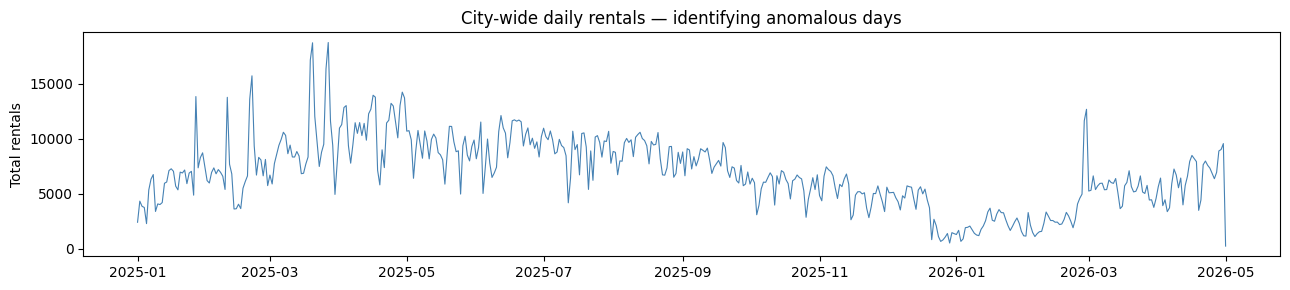

count     486.00
mean     6886.08
std      3167.78
min       226.00
25%      4883.00
50%      6724.50
75%      9148.00
max     18771.00
Name: city_total, dtype: float64


In [4]:
# City-wide daily totals
city_daily = (
    demand.groupby('date')['rentals'].sum()
    .rename('city_total')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(city_daily['date'], city_daily['city_total'], color='steelblue', linewidth=0.8)
ax.set_title('City-wide daily rentals — identifying anomalous days')
ax.set_ylabel('Total rentals')
plt.tight_layout()
plt.show()

print(city_daily['city_total'].describe())

In [5]:
# Threshold: city-wide total below the 2nd percentile flags an anomalous day
ANOMALY_THRESHOLD = city_daily['city_total'].quantile(0.02)
anomalous_dates = city_daily.loc[city_daily['city_total'] < ANOMALY_THRESHOLD, 'date']

print(f'Threshold (2nd percentile): {ANOMALY_THRESHOLD:.0f} city-wide rentals')
print(f'Anomalous dates flagged: {len(anomalous_dates)}')
print(anomalous_dates.dt.date.values)

# Show their city-wide totals and avg active stations for context
anomaly_info = demand[demand['date'].isin(anomalous_dates)].groupby('date').agg(
    city_rentals=('rentals', 'sum'),
    avg_active_stations=('active_stations', 'mean'),
).round(1)
print('\nAnomalous day details:')
print(anomaly_info.to_string())

Threshold (2nd percentile): 1126 city-wide rentals
Anomalous dates flagged: 10
[datetime.date(2025, 12, 21) datetime.date(2025, 12, 24)
 datetime.date(2025, 12, 25) datetime.date(2025, 12, 26)
 datetime.date(2025, 12, 27) datetime.date(2025, 12, 29)
 datetime.date(2026, 1, 3) datetime.date(2026, 1, 4)
 datetime.date(2026, 2, 5) datetime.date(2026, 5, 1)]

Anomalous day details:
            city_rentals  avg_active_stations
date                                         
2025-12-21        815.00               118.60
2025-12-24       1096.00                95.40
2025-12-25        654.00                65.00
2025-12-26        788.00                85.10
2025-12-27       1043.00                81.10
2025-12-29        507.00                70.50
2026-01-03        657.00                77.50
2026-01-04        884.00                90.60
2026-02-05       1095.00                95.60
2026-05-01        226.00                46.50


In [6]:
# Set rentals to NaN for anomalous dates
# Lag and rolling features computed from these rows will propagate NaN,
# which will be dropped during the final dropna.
demand.loc[demand['date'].isin(anomalous_dates), 'rentals'] = np.nan

n_nulled = demand['rentals'].isna().sum()
print(f'Rows NaN-ed out: {n_nulled} ({n_nulled / len(demand) * 100:.1f}% of demand rows)')

Rows NaN-ed out: 111 (1.9% of demand rows)


## 3. Temporal Features

Calendar signals that capture day-of-week and seasonal patterns, plus Berlin public holidays.

In [ ]:
df = demand.sort_values(['district', 'date']).copy()

df['district'] = pd.Categorical(df['district'])

# Relative demand: rentals per active station — normalises for network size changes
# across time (Nextbike contracted from ~4,500 → ~2,000 stations) and across districts.
df['relative_demand'] = df['rentals'] / df['active_stations']

years = df['date'].dt.year.unique().tolist()
berlin_holidays = set(holidays.Germany(state='BE', years=years).keys())
print(f'Berlin holidays in dataset: {sorted(berlin_holidays)}')
print(f'\nRelative demand stats:')
print(df.groupby('district')['relative_demand'].mean().sort_values(ascending=False).round(2).to_string())

In [8]:
df['dow']        = df['date'].dt.dayofweek          # 0=Monday
df['month']      = df['date'].dt.month
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
df['is_holiday'] = df['date'].dt.date.isin(berlin_holidays).astype(int)
df['season']     = df['date'].dt.month.map({
    12: 'winter', 1: 'winter',  2: 'winter',
     3: 'spring', 4: 'spring',  5: 'spring',
     6: 'summer', 7: 'summer',  8: 'summer',
     9: 'autumn', 10: 'autumn', 11: 'autumn',
})

print('Temporal features added:', ['dow', 'month', 'is_weekend', 'is_holiday', 'season'])
print(f'\nHoliday days in data: {df["is_holiday"].sum() // df["district"].nunique()}')
df[['date', 'district', 'rentals', 'dow', 'month', 'is_weekend', 'is_holiday', 'season']].head(14)

Temporal features added: ['dow', 'month', 'is_weekend', 'is_holiday', 'season']

Holiday days in data: 15


,date,district,rentals,dow,month,is_weekend,is_holiday,season
0,2025-01-01,Charlottenburg-Wilmersdorf,152.00,2,1,0,1,winter
1,2025-01-02,Charlottenburg-Wilmersdorf,351.00,3,1,0,0,winter
2,2025-01-03,Charlottenburg-Wilmersdorf,363.00,4,1,0,0,winter
3,2025-01-04,Charlottenburg-Wilmersdorf,293.00,5,1,1,0,winter
4,2025-01-05,Charlottenburg-Wilmersdorf,181.00,6,1,1,0,winter
5,2025-01-06,Charlottenburg-Wilmersdorf,518.00,0,1,0,0,winter
6,2025-01-07,Charlottenburg-Wilmersdorf,812.00,1,1,0,0,winter
7,2025-01-08,Charlottenburg-Wilmersdorf,789.00,2,1,0,0,winter
8,2025-01-09,Charlottenburg-Wilmersdorf,331.00,3,1,0,0,winter
9,2025-01-10,Charlottenburg-Wilmersdorf,389.00,4,1,0,0,winter


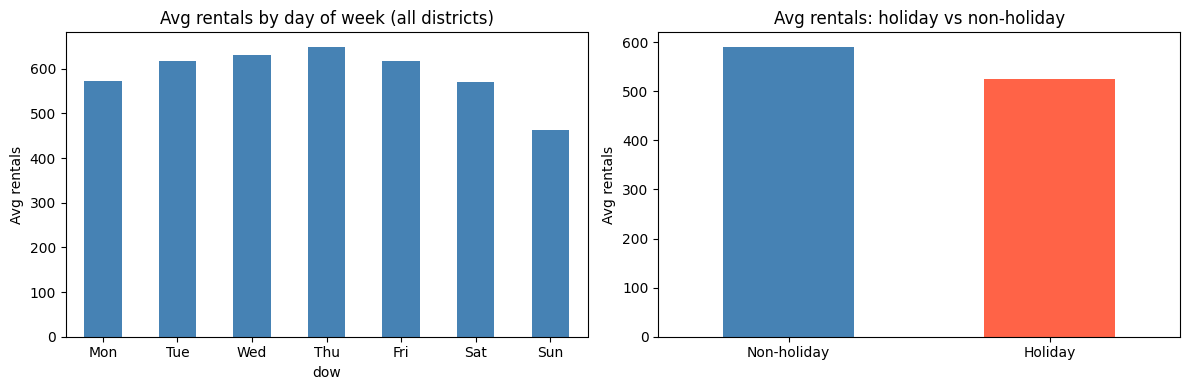

In [9]:
# Average demand by day-of-week — sanity check
dow_avg = (
    df.groupby('dow')['rentals'].mean()
    .rename(index={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'})
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dow_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg rentals by day of week (all districts)')
axes[0].set_ylabel('Avg rentals')
axes[0].tick_params(axis='x', rotation=0)

holiday_avg = df.groupby('is_holiday')['rentals'].mean()
holiday_avg.index = ['Non-holiday', 'Holiday']
holiday_avg.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Avg rentals: holiday vs non-holiday')
axes[1].set_ylabel('Avg rentals')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Lag Features

Past demand at 1, 2, 7, and 14-day lags, computed **per district**.
The 7-day lag captures the same day last week (strongest single predictor from EDA).
Any lag that references a NaN-ed anomalous day will itself be NaN and dropped at save time.

In [ ]:
grp = df.groupby('district')['relative_demand']

for lag in LAG_DAYS:
    df[f'lag_{lag}d'] = grp.shift(lag)

lag_cols = [f'lag_{lag}d' for lag in LAG_DAYS]
print('Lag NaN counts (warm-up rows + propagated anomaly NaNs):')
print(df[lag_cols].isna().sum())

In [ ]:
# Verify: lags are now in relative demand units (rentals / active_stations)
sample = df[df['district'] == 'Mitte'].sort_values('date')[
    ['date', 'rentals', 'active_stations', 'relative_demand', 'lag_1d', 'lag_7d']
].head(16)
print('Mitte — lag sanity check (lags in relative demand units):')
print(sample.to_string(index=False))

## 5. Rolling Features

Smoothed demand signal: 3/7/14-day rolling mean and std, computed over **already-shifted** values
to avoid any target leakage (rolling always looks at `t-1` and earlier).

In [ ]:
for window in ROLL_WINDOWS:
    df[f'roll_{window}d_mean'] = df.groupby('district')['relative_demand'].transform(
        lambda s, w=window: s.shift(1).rolling(w).mean()
    )
    df[f'roll_{window}d_std'] = df.groupby('district')['relative_demand'].transform(
        lambda s, w=window: s.shift(1).rolling(w).std()
    )

roll_cols = [f'roll_{w}d_{s}' for w in ROLL_WINDOWS for s in ['mean', 'std']]
print('Rolling NaN counts:')
print(df[roll_cols].isna().sum())

In [ ]:
# Visual check: actual relative demand vs rolling mean for one district
district_plot = 'Mitte'
d = df[df['district'] == district_plot].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(d['date'], d['relative_demand'], color='steelblue', alpha=0.4, label='actual (rel.)')
ax.plot(d['date'], d['roll_7d_mean'], color='tomato', linewidth=2, label='7d rolling mean (rel.)')
ax.plot(d['date'], d['roll_14d_mean'], color='darkred', linewidth=1.5, linestyle='--', label='14d rolling mean (rel.)')
ax.set_title(f'{district_plot} — relative demand (rentals/station) vs rolling mean')
ax.set_ylabel('Rentals per active station')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Network Feature

`active_stations` is already included in the demand table. It captures changes in network coverage
that affect total district demand independently of weather or calendar effects.

In [14]:
print('active_stations stats per district:')
print(df.groupby('district')['active_stations'].describe().round(1).to_string())

active_stations stats per district:
                            count   mean    std    min    25%    50%    75%    max
district                                                                          
Charlottenburg-Wilmersdorf 486.00 287.40 124.60  29.00 184.00 283.50 400.00 703.00
Friedrichshain-Kreuzberg   486.00 424.40 124.70 118.00 338.00 397.00 482.50 719.00
Lichtenberg                486.00 176.40  38.40  48.00 159.00 183.00 198.00 329.00
Marzahn-Hellersdorf        475.00  15.50  20.90   1.00   5.00  10.00  20.00 220.00
Mitte                      486.00 590.20 139.50 120.00 508.00 565.00 668.80 950.00
Neukölln                   486.00 173.10  44.70  60.00 143.00 172.00 190.00 313.00
Pankow                     486.00 210.90  67.30  50.00 162.00 204.00 250.00 432.00
Reinickendorf              486.00  22.70  10.70   2.00  17.00  21.00  28.00 104.00
Spandau                    448.00  16.90  19.40   1.00   2.00  16.00  27.00 144.00
Steglitz-Zehlendorf        486.00  72.10  30.20  10

## 7. Weather Features

Today's weather is used to predict tomorrow's demand — this is valid because weather forecasts
are available in advance, and observed weather on day *t* correlates with demand on day *t+1*.

In [15]:
df = df.merge(weather[['date'] + WEATHER_COLS], on='date', how='left')

print('Weather merge — NaN check:')
print(df[WEATHER_COLS].isna().sum())
print(f'\nRows after merge: {len(df)}')

Weather merge — NaN check:
temperature_2m          0
apparent_temperature    0
precipitation           0
rain                    0
snowfall                0
wind_speed_10m          0
cloud_cover             0
relative_humidity_2m    0
dtype: int64

Rows after merge: 5783


## 8. Target Variable

`relative_demand_tomorrow` = rentals(t+1) / active_stations(t+1) per district.

Using relative demand as the target normalises for the Nextbike network contraction and
makes all districts comparable — the model minimises relative errors rather than absolute ones.

`rentals_tomorrow` (absolute) is kept as a reference column for operational evaluation.

In [ ]:
df = df.sort_values(['district', 'date'])

# Primary target: relative demand tomorrow (rentals/active_stations)
df['relative_demand_tomorrow'] = df.groupby('district')['relative_demand'].shift(-1)

# Reference column: absolute rentals tomorrow (for evaluation / back-conversion)
df['rentals_tomorrow'] = df.groupby('district')['rentals'].shift(-1)

print('relative_demand_tomorrow NaN count:', df['relative_demand_tomorrow'].isna().sum())
print('\nTarget distribution:')
print(df['relative_demand_tomorrow'].describe())

In [ ]:
fig = px.box(
    df.dropna(subset=['relative_demand_tomorrow']),
    x='district', y='relative_demand_tomorrow',
    title='Distribution of relative_demand_tomorrow per district (rentals per active station)',
    labels={'relative_demand_tomorrow': 'Rentals / active station (next day)', 'district': ''},
    template='simple_white', height=450,
)
fig.update_xaxes(tickangle=30)
fig.show()

## 9. Feature Matrix — Quality Check

In [18]:
feature_cols = [
    'district',
    'dow', 'month', 'is_weekend', 'is_holiday',
    *[f'lag_{l}d' for l in LAG_DAYS],
    *[f'roll_{w}d_{s}' for w in ROLL_WINDOWS for s in ['mean', 'std']],
    'active_stations',
    *WEATHER_COLS,
]

print(f'Total features: {len(feature_cols)}')
print(f'Total rows    : {len(df)}')
print(f'Valid rows    : {df[feature_cols].dropna().shape[0]}  (all features present, excl. target NaNs)')

print('\nNaN counts per feature:')
nans = df[feature_cols].isna().sum()
print(nans[nans > 0].to_string())

Total features: 24
Total rows    : 5783
Valid rows    : 5131  (all features present, excl. target NaNs)

NaN counts per feature:
lag_1d           112
lag_2d           124
lag_7d           184
lag_14d          268
roll_3d_mean     236
roll_3d_std      236
roll_7d_mean     400
roll_7d_std      400
roll_14d_mean    652
roll_14d_std     652


In [ ]:
# Valid rows per district
valid_per_district = (
    df.dropna(subset=feature_cols + ['relative_demand_tomorrow'])
    .groupby('district')
    .size()
    .rename('valid_rows')
    .sort_values()
)
print(valid_per_district.to_string())

In [ ]:
# Feature correlation with relative_demand_tomorrow (numeric features only)
numeric_features = [c for c in feature_cols if c not in ('district', 'season')]
corr = (
    df[numeric_features + ['relative_demand_tomorrow']]
    .dropna()
    .corr()['relative_demand_tomorrow']
    .drop('relative_demand_tomorrow')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 7))
corr.plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'steelblue' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature correlation with relative_demand_tomorrow (all districts)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

print(corr.to_string())

## 10. Save Feature Matrix

In [ ]:
out_cols = ['date', 'district', 'rentals', 'relative_demand', *feature_cols,
            'season', 'relative_demand_tomorrow', 'rentals_tomorrow']
out_cols = list(dict.fromkeys(out_cols))  # deduplicate (district in both identifier and features)
features = df[out_cols].reset_index(drop=True)

out_path = FEATURES_DIR / 'features.parquet'
features.to_parquet(out_path, index=False)

print(f'Saved {len(features):,} rows × {len(features.columns)} columns to {out_path}')
print(f'Valid modelling rows (no NaN in features or target): {features.dropna(subset=feature_cols + ["relative_demand_tomorrow"]).shape[0]:,}')
features.head()